In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
#df=pd.read_csv(r"C:\Data Science\Project\Analysis\Job_Market_Salary_Analysis\linkedin_jobs_final.csv")
df = pd.read_csv("linkedin_jobs_final.csv")
df.head()

,title,company,location,job_url,posted_text,posted_date,experience,salary,skills,job_type,salary_min,salary_max
0,Data Scientist-Artificial Intelligence,IBM,"Kochi, Kerala, India",https://in.linkedin.com/jobs/view/data-scienti...,18 hours ago,2026-08-25,Mid-Senior level,"₹1,000,000.00\n -\n ₹3,0...","Python, SQL, Machine Learning, Artificial Inte...",Full-time,1000000.0,3000000.0
1,Senior Data Scientist - I,MetLife,"Pune Division, Maharashtra, India",https://in.linkedin.com/jobs/view/senior-data-...,22 hours ago,2026-08-25,Mid-Senior level,NaN,"Python, Machine Learning, NLP, TensorFlow, PyT...",Full-time,NaN,NaN
2,Senior Data Scientist,SourcingXPress,"Gurgaon, Haryana, India",https://in.linkedin.com/jobs/view/senior-data-...,5 months ago,2026-03-16,Mid-Senior level,"Base pay range ₹2,000,000.00/yr - ₹4,000,000.0...","Python, Machine Learning, Deep Learning, AWS, ...",Full-time,2000000.0,4000000.0
3,Sr Advanced Data Scientist,Honeywell Technologies,"Pune Division, Maharashtra, India",https://in.linkedin.com/jobs/view/sr-advanced-...,1 week ago,2026-08-18,Mid-Senior level,NaN,"Python, R, Machine Learning, Azure, Databricks",Full-time,NaN,NaN
4,Senior Data Scientist I,MetLife,"Pune Division, Maharashtra, India",https://in.linkedin.com/jobs/view/senior-data-...,3 weeks ago,2026-08-03,Mid-Senior level,NaN,"Python, Machine Learning, NLP, TensorFlow, PyT...",Full-time,NaN,NaN


In [4]:
df.shape

(600, 12)

In [5]:
df.columns

Index(['title', 'company', 'location', 'job_url', 'posted_text', 'posted_date',
       'experience', 'salary', 'skills', 'job_type', 'salary_min',
       'salary_max'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        600 non-null    str    
 1   company      600 non-null    str    
 2   location     600 non-null    str    
 3   job_url      600 non-null    str    
 4   posted_text  600 non-null    str    
 5   posted_date  600 non-null    str    
 6   experience   574 non-null    str    
 7   salary       298 non-null    str    
 8   skills       566 non-null    str    
 9   job_type     574 non-null    str    
 10  salary_min   298 non-null    float64
 11  salary_max   298 non-null    float64
dtypes: float64(2), str(10)
memory usage: 56.4 KB


In [7]:
df.describe(include="all")

,title,company,location,job_url,posted_text,posted_date,experience,salary,skills,job_type,salary_min,salary_max
count,600,600,600,600,600,600,574,298,566,574,2.980000e+02,2.980000e+02
unique,81,94,44,600,27,48,4,34,106,1,NaN,NaN
top,Senior Data Scientist,Deloitte,"Pune Division, Maharashtra, India",https://in.linkedin.com/jobs/view/data-scienti...,1 week ago,2026-08-25,Mid-Senior level,"₹1,000,000.00\n -\n ₹3,0...","Python, SQL, Machine Learning, Artificial Inte...",Full-time,NaN,NaN
freq,98,20,80,1,136,56,437,68,17,574,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.576848e+06,2.852620e+06
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.234327e+06,1.673333e+06
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+01,2.000000e+01
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+06,1.800000e+06
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+06,3.000000e+06
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+06,4.000000e+06


In [8]:
df.isna().sum()

title            0
company          0
location         0
job_url          0
posted_text      0
posted_date      0
experience      26
salary         302
skills          34
job_type        26
salary_min     302
salary_max     302
dtype: int64

In [9]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

print(df.columns.tolist())

print("Duplicated:",df.duplicated().sum())

Rows: 600
Columns: 12
['title', 'company', 'location', 'job_url', 'posted_text', 'posted_date', 'experience', 'salary', 'skills', 'job_type', 'salary_min', 'salary_max']
Duplicated: 0


In [10]:
num_col=df.select_dtypes(include="number").columns

for col in num_col:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1 -1.5 * IQR
    upper=Q3 +1.5 * IQR

    outliers=df[(df[col]<lower)| (df[col]>upper)]

    print(f"{col} -> Outliers:{len(outliers)}")

salary_min -> Outliers:39
salary_max -> Outliers:0


Index(['salary_min', 'salary_max'], dtype='str')


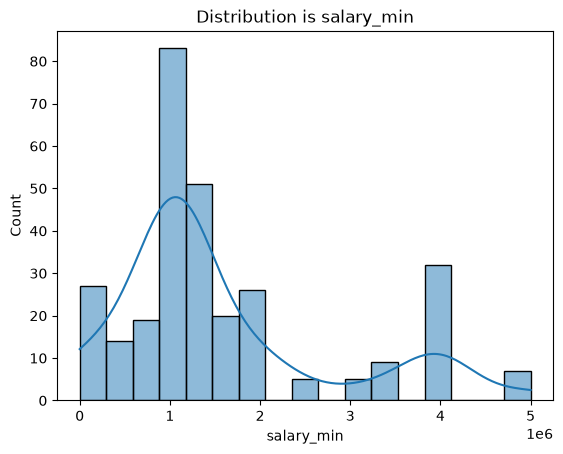

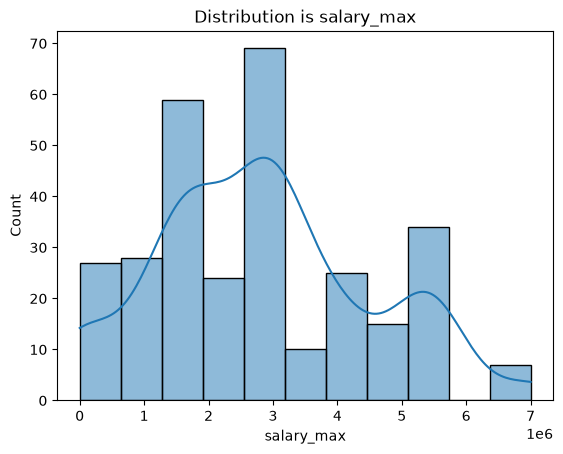

In [11]:
# Univariate Analysis

num_cols=df.select_dtypes(include="number").columns

print(num_cols)

for col in num_cols:
    sns.histplot(data=df,x=col,kde=True)
    plt.title(f"Distribution is {col}")
    plt.show()

In [12]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols)

Index(['title', 'company', 'location', 'job_url', 'posted_text', 'posted_date',
       'experience', 'salary', 'skills', 'job_type'],
      dtype='str')


C:\Users\Ritesh\AppData\Local\Temp\ipykernel_2784\1265589173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [13]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())


title
title
Senior Data Scientist                     98
Data Scientist                            40
Lead Data Scientist                       32
Data Scientist-Artificial Intelligence    18
Sr Advanced Data Scientist                16
Name: count, dtype: int64

company
company
Deloitte          20
IBM               18
SourcingXPress    18
Cognizant         18
StraViso          18
Name: count, dtype: int64

location
location
Pune Division, Maharashtra, India    80
Gurugram, Haryana, India             60
Chennai, Tamil Nadu, India           60
Hyderabad, Telangana, India          56
Bengaluru, Karnataka, India          56
Name: count, dtype: int64

job_url
job_url
https://in.linkedin.com/jobs/view/data-scientist-artificial-intelligence-at-ibm-4446241710?position=1&pageNum=0&refId=x8S%2B68uVhJjbnbv4CmsPww%3D%3D&trackingId=SvOZkJNmAmrAO7HXXxVCQg%3D%3D               1
https://in.linkedin.com/jobs/view/senior-data-scientist-i-at-metlife-4455731862?position=2&pageNum=0&refId=x8S%2B68uVhJjb

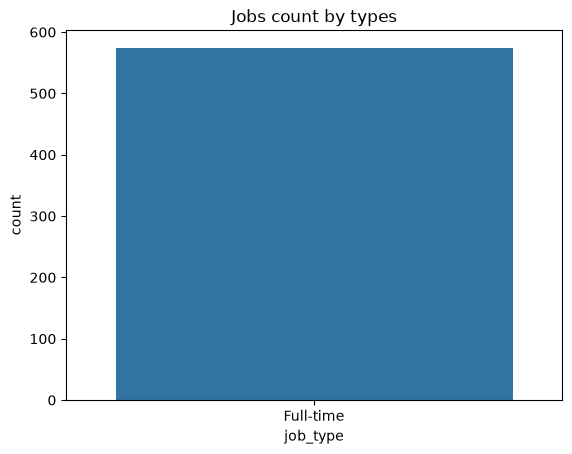

In [14]:
sns.countplot(data=df,x="job_type")
plt.title("Jobs count by types")
plt.show()

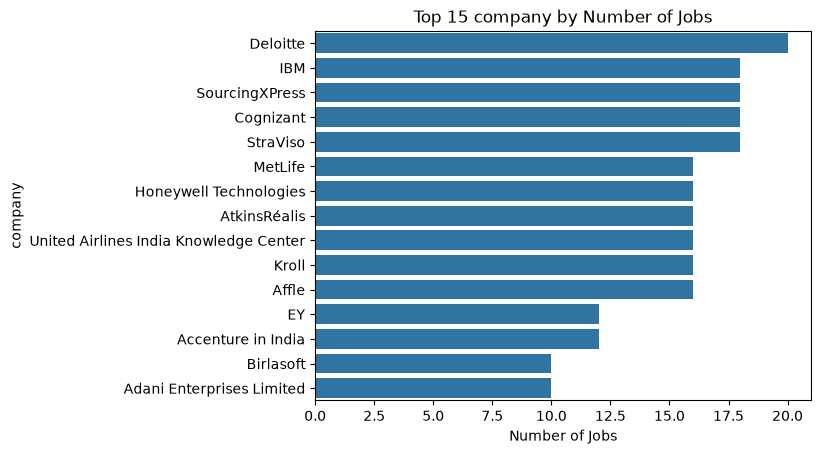

In [15]:
top_company = df["company"].value_counts().head(15).index

sns.countplot(
    data=df[df["company"].isin(top_company)],
    y="company",
    order=top_company
)

plt.title("Top 15 company by Number of Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("company")
plt.show()

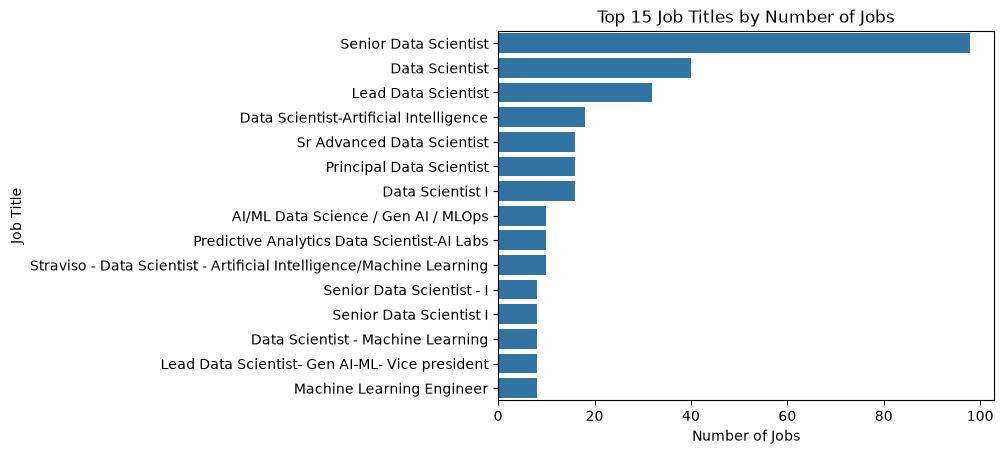

In [16]:
top_titles = df["title"].value_counts().head(15).index

sns.countplot(
    data=df[df["title"].isin(top_titles)],
    y="title",
    order=top_titles
)

plt.title("Top 15 Job Titles by Number of Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")
plt.show()

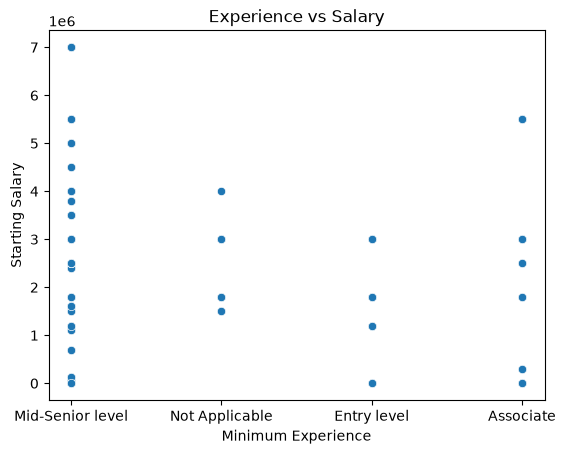

In [17]:
# Bivariate Analysis

sns.scatterplot(data=df, x="experience", y="salary_max")

plt.title("Experience vs Salary")
plt.xlabel("Minimum Experience")
plt.ylabel("Starting Salary")
plt.show()

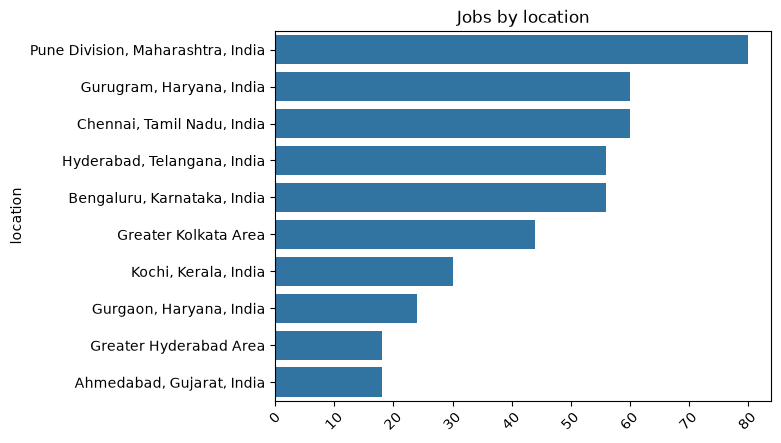

In [18]:
top_location=df["location"].value_counts().head(10)

sns.barplot(
    x=top_location.values,
    y=top_location.index
)
plt.title("Jobs by location")
plt.xticks(rotation=45)
plt.show()

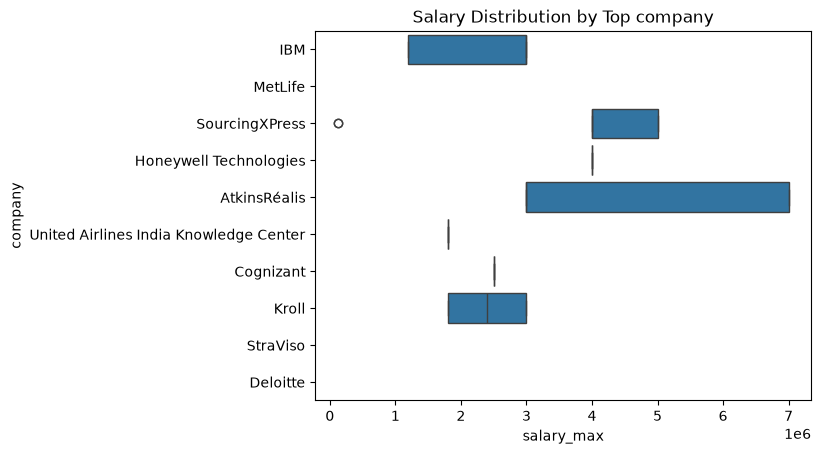

In [19]:
top_roles = df["company"].value_counts().head(10).index

sns.boxplot(
    data=df[df["company"].isin(top_roles)],
    x="salary_max",
    y="company"
)

plt.title("Salary Distribution by Top company")
plt.show()

In [20]:
df[num_cols].corr()

,salary_min,salary_max
salary_min,1.000000,0.896156
salary_max,0.896156,1.000000


In [21]:
df.columns

Index(['title', 'company', 'location', 'job_url', 'posted_text', 'posted_date',
       'experience', 'salary', 'skills', 'job_type', 'salary_min',
       'salary_max'],
      dtype='str')

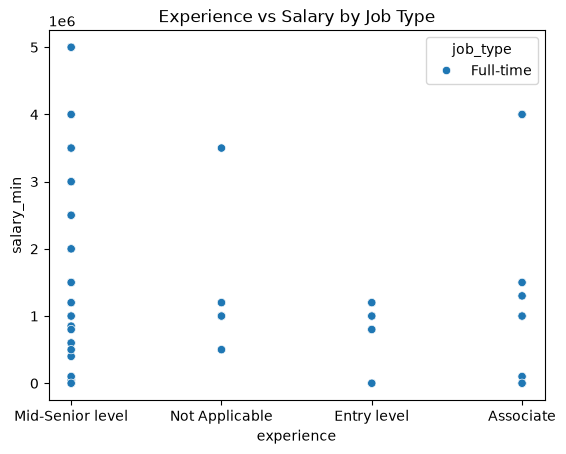

In [22]:
# Multivariate Analysis

sns.scatterplot(
    data=df,
    x="experience",
    y="salary_min",
    hue="job_type"
)

plt.title("Experience vs Salary by Job Type")
plt.show()

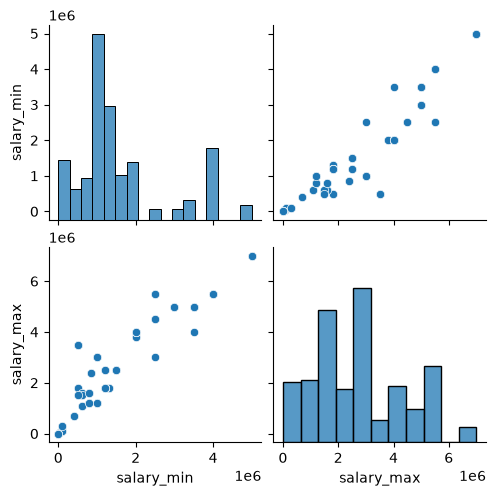

In [23]:

selected_cols = [
    "salary_min",
    "salary_max"
]

sns.pairplot(df[selected_cols])
plt.show()

In [24]:
# Correlation Analysis

corr = df[num_cols].corr()

print(corr)

            salary_min  salary_max
salary_min    1.000000    0.896156
salary_max    0.896156    1.000000


In [25]:
top_roles = df["title"].value_counts().head(10)

print(top_roles)


title
Senior Data Scientist                                                   98
Data Scientist                                                          40
Lead Data Scientist                                                     32
Data Scientist-Artificial Intelligence                                  18
Sr Advanced Data Scientist                                              16
Principal Data Scientist                                                16
Data Scientist I                                                        16
AI/ML Data Science / Gen AI / MLOps                                     10
Predictive Analytics Data Scientist-AI Labs                             10
Straviso - Data Scientist - Artificial Intelligence/Machine Learning    10
Name: count, dtype: int64


In [26]:
print(df[["salary_min", "salary_max"]].describe())

         salary_min    salary_max
count  2.980000e+02  2.980000e+02
mean   1.576848e+06  2.852620e+06
std    1.234327e+06  1.673333e+06
min    1.200000e+01  2.000000e+01
25%    1.000000e+06  1.800000e+06
50%    1.200000e+06  3.000000e+06
75%    2.000000e+06  4.000000e+06
max    5.000000e+06  7.000000e+06


In [27]:
print(df[["salary_min", "salary_max"]].corr())

            salary_min  salary_max
salary_min    1.000000    0.896156
salary_max    0.896156    1.000000
